# Loading the Data

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# Connect to the database
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(BASE_DIR, "data", "supply_chain.db")

conn = sqlite3.connect(db_path)

# Load our analytics table
df = pd.read_sql_query("SELECT * FROM analytics_order_summary", conn)
conn.close()

print(f"Successfully loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head())

Successfully loaded 100,000 rows and 11 columns.


,order_id,supplier_id,supplier_name,location,order_date,delivery_date,order_quantity,unit_cost,total_order_value,status,calculated_lead_time
0,ORD_000019,SUP_001,Apex Logistics,"New York, USA",2025-06-18,2025-07-04,613,384.21,235520.73,Delivered,16.0
1,ORD_000024,SUP_001,Apex Logistics,"New York, USA",2024-02-25,2024-03-15,455,90.27,41072.85,Delivered,19.0
2,ORD_000025,SUP_001,Apex Logistics,"New York, USA",2024-05-03,2024-05-09,219,463.68,101545.92,Delivered,6.0
3,ORD_000034,SUP_001,Apex Logistics,"New York, USA",2024-01-18,2024-02-06,695,177.65,123466.75,Delivered,19.0
4,ORD_000039,SUP_001,Apex Logistics,"New York, USA",2024-02-20,2024-02-23,160,303.85,48616.00,Delivered,3.0


/var/folders/05/9zy4zl9j6dgcxmd0nt6mhgpw0000gn/T/ipykernel_38070/4288484564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='status', palette='Set2', order=df['status'].value_counts().index)


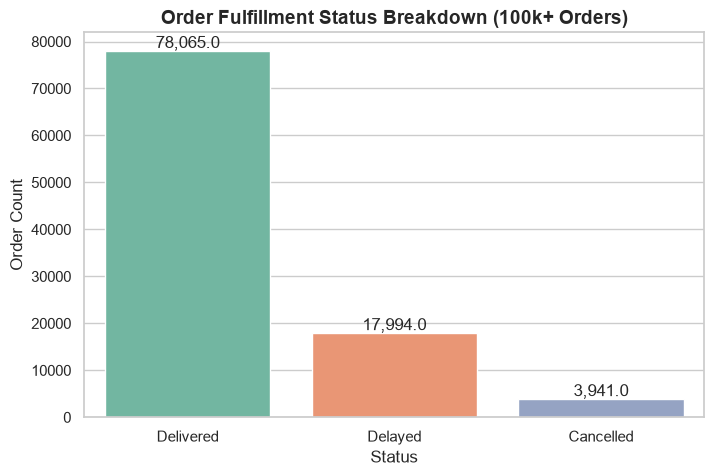

/var/folders/05/9zy4zl9j6dgcxmd0nt6mhgpw0000gn/T/ipykernel_38070/4288484564.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='calculated_lead_time', palette='Set3')


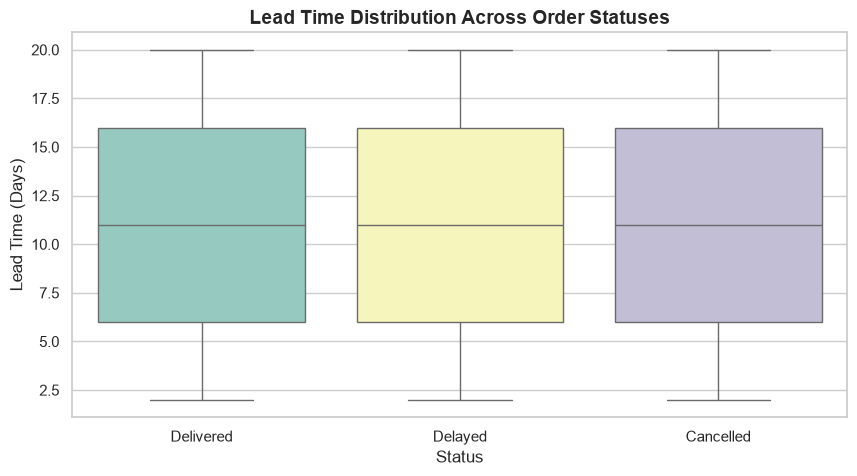

In [3]:
# 1. Order Status Distribution Chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='status', palette='Set2', order=df['status'].value_counts().index)
plt.title('Order Fulfillment Status Breakdown (100k+ Orders)', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Order Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# 2. Lead Time Distribution by Status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='status', y='calculated_lead_time', palette='Set3')
plt.title('Lead Time Distribution Across Order Statuses', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Lead Time (Days)', fontsize=12)
plt.show()

# Supplier Cost vs. Lead Time Performance Matrix

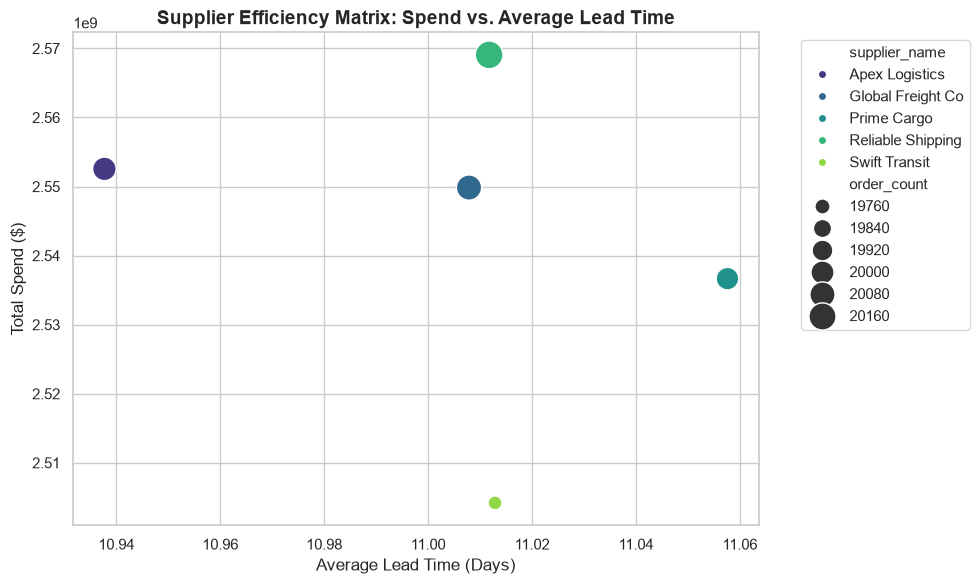

In [4]:
# Aggregate data by supplier
supplier_summary = df.groupby('supplier_name').agg(
    avg_lead_time=('calculated_lead_time', 'mean'),
    total_spend=('total_order_value', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=supplier_summary,
    x='avg_lead_time',
    y='total_spend',
    size='order_count',
    sizes=(100, 400),
    hue='supplier_name',
    palette='viridis',
    legend='brief'
)

plt.title('Supplier Efficiency Matrix: Spend vs. Average Lead Time', fontsize=14, fontweight='bold')
plt.xlabel('Average Lead Time (Days)', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Delay Rate by Supplier (%)

/var/folders/05/9zy4zl9j6dgcxmd0nt6mhgpw0000gn/T/ipykernel_38070/2570593609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=delay_by_supplier, x='supplier_name', y='delay_percentage', palette='magma')


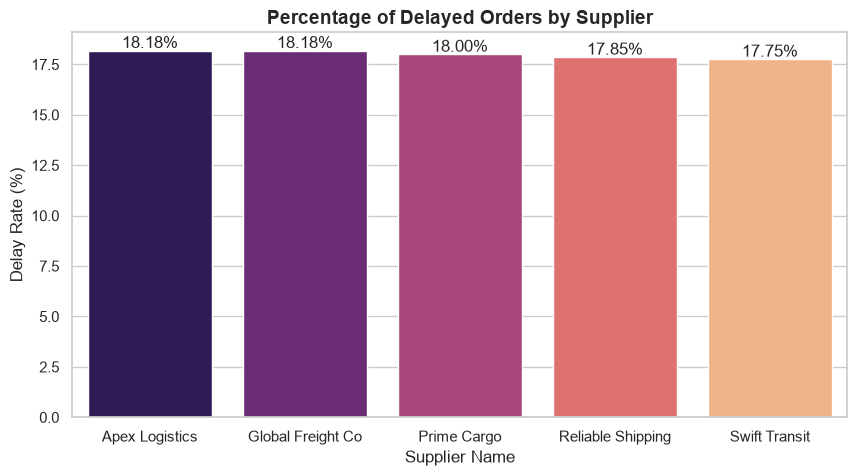

In [5]:
# Calculate delay percentage per supplier
df['is_delayed'] = df['status'].apply(lambda x: 1 if x == 'Delayed' else 0)
delay_by_supplier = df.groupby('supplier_name')['is_delayed'].mean().reset_index()
delay_by_supplier['delay_percentage'] = delay_by_supplier['is_delayed'] * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=delay_by_supplier, x='supplier_name', y='delay_percentage', palette='magma')
plt.title('Percentage of Delayed Orders by Supplier', fontsize=14, fontweight='bold')
plt.xlabel('Supplier Name', fontsize=12)
plt.ylabel('Delay Rate (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# Monthly Order Trend Over Time

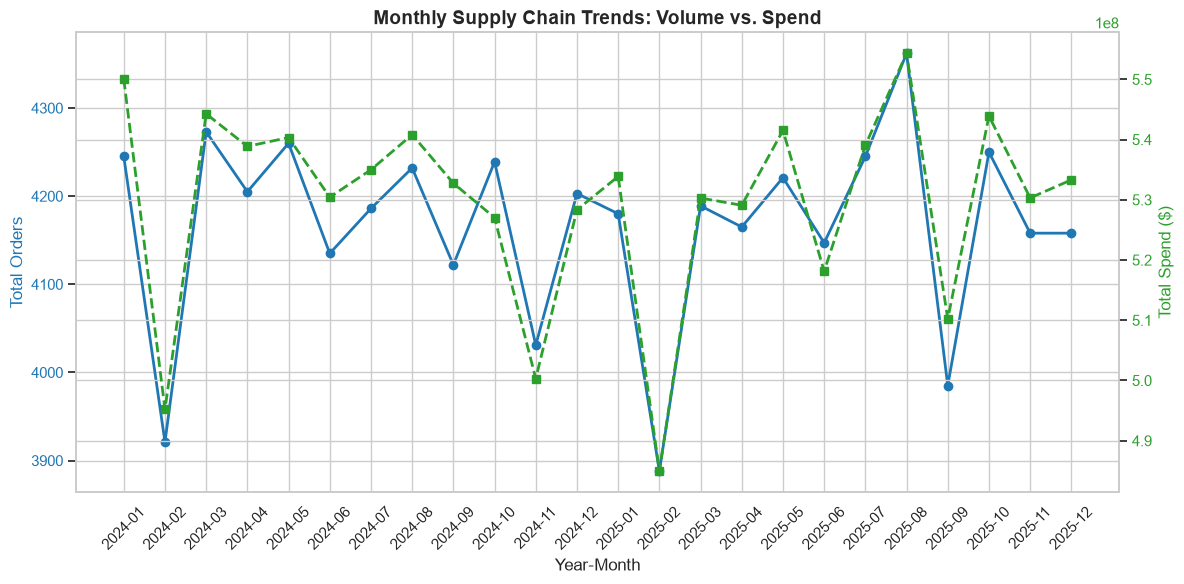

In [6]:
# Convert order_date to datetime and extract Year-Month
df['order_date_dt'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date_dt'].dt.to_period('M').astype(str)

monthly_trend = df.groupby('year_month').agg(
    total_orders=('order_id', 'count'),
    total_spend=('total_order_value', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Year-Month', fontsize=12)
ax1.set_ylabel('Total Orders', color=color, fontsize=12)
ax1.plot(monthly_trend['year_month'], monthly_trend['total_orders'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Total Spend ($)', color=color, fontsize=12)
ax2.plot(monthly_trend['year_month'], monthly_trend['total_spend'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Supply Chain Trends: Volume vs. Spend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Heatmap of Numeric Supply Chain Variables

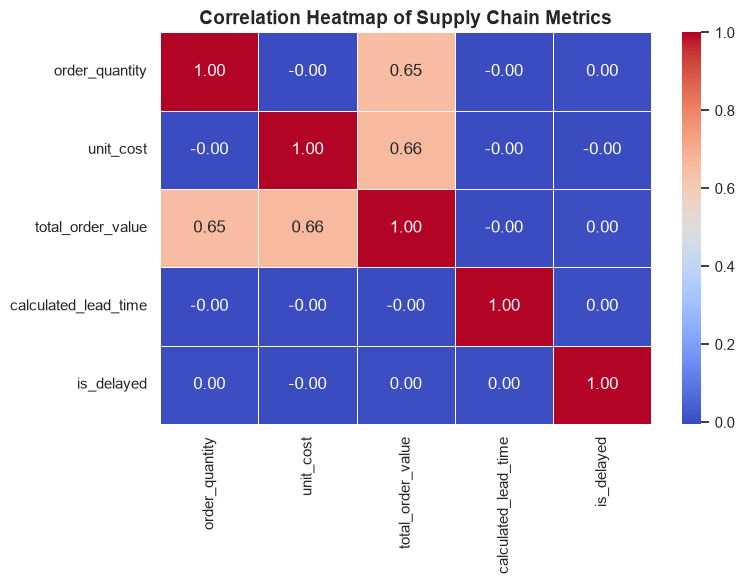

In [7]:
# Select key numeric columns for correlation analysis
numeric_cols = ['order_quantity', 'unit_cost', 'total_order_value', 'calculated_lead_time', 'is_delayed']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Correlation Heatmap of Supply Chain Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Order Volume Distribution by Location

/var/folders/05/9zy4zl9j6dgcxmd0nt6mhgpw0000gn/T/ipykernel_38070/598104739.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=location_counts, x='location', y='order_count', palette='crest')


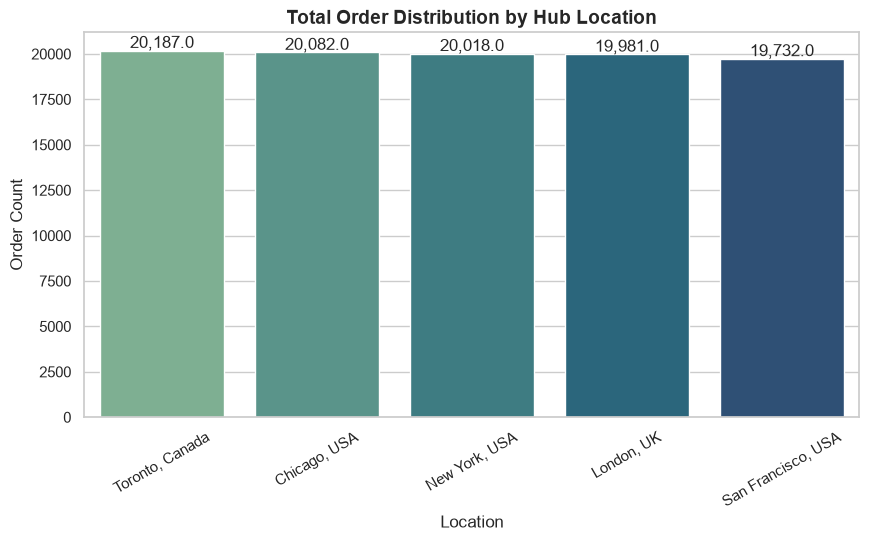

In [8]:
# Check order distribution across supplier locations
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'order_count']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=location_counts, x='location', y='order_count', palette='crest')
plt.title('Total Order Distribution by Hub Location', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()